# **TWITTER SENTIMENT ANALYSIS - PROJECT PREDICTION SENTIMENT ANALYSIS**

# Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import string
import warnings
import tabulate

# Regular Expression
import re

# Text Manipulation --> Natural Languages Tool Kit
import nltk
from nltk.stem.porter import *
# Tokenizer, word_tokenizer
from nltk.tokenize import word_tokenize
# Stopwords
from nltk.corpus import stopwords

# WordCloud --> To Show All Words in dataset
from wordcloud import WordCloud as wc

pd.set_option('display.max_colwidth', 200)
warnings.filterwarnings('ignore', category=DeprecationWarning)

%matplotlib inline

In [2]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Gathering Data

In [3]:
df_train = pd.read_csv('../data/train_E6oV3lV.csv')
df_test = pd.read_csv('../data/test_tweets_anuFYb8.csv')

display(df_train.head(3))  # With labels
display(df_test.head(3))  # Without labels

print(f'Train Shape : {df_train.shape}, Test Shape : {df_test.shape}')

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction. #run
1,2,0,@user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx. #disapointed #getthanked
2,3,0,bihday your majesty


,id,tweet
0,31963,#studiolife #aislife #requires #passion #dedication #willpower to find #newmaterialsâ¦
1,31964,@user #white #supremacists want everyone to see the new â #birdsâ #movie â and hereâs why
2,31965,safe ways to heal your #acne!! #altwaystoheal #healthy #healing!!


Train Shape : (31962, 3), Test Shape : (17197, 2)


# Data Preparation

## Inspection Data

In [4]:
print(f'Labels: {df_train['label'].unique()}')  # [0,1]

print(f'{'='*30} VALUE COUNTS OF THIS LABELS {'='*30}')

print(f'Value Counts : \n{df_train['label'].value_counts()}')

labels_no = df_train[df_train['label'] == 0]
labels_yes = df_train[df_train['label'] == 1]

print(f'{'='*30}  LABELS  {'='*30}')
print(f'{'='*30} Label No {'='*30}')
print(labels_no.head(3).to_markdown())
print(f'{'='*30} Label Yes {'='*30}')
print(labels_yes.head(3).to_markdown())

Labels: [0 1]
============================== VALUE COUNTS OF THIS LABELS ==============================
Value Counts : 
label
0    29720
1     2242
Name: count, dtype: int64
==============================  LABELS  ==============================
============================== Label No ==============================
|    |   id |   label | tweet                                                                                                                      |
|---:|-----:|--------:|:---------------------------------------------------------------------------------------------------------------------------|
|  0 |    1 |       0 | @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run                      |
|  1 |    2 |       0 | @user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx.    #disapointed #getthanked |
|  2 |    3 |       0 | bihday your majesty                                             

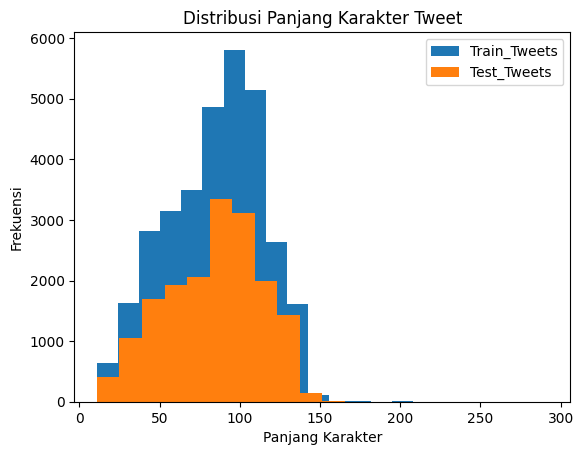

In [5]:
len_train = df_train['tweet'].str.len()
len_test = df_test['tweet'].str.len()

plt.hist(len_train, bins=20, label='Train_Tweets')
plt.hist(len_test, bins=20, label='Test_Tweets')
plt.legend()
plt.title('Distribusi Panjang Karakter Tweet')
plt.xlabel('Panjang Karakter')
plt.ylabel('Frekuensi')
plt.show()

Meskipun data_train lebih banyak, tapi ternyata panjang karakter data_train maupun data_test hampir sama.

## Combine Train and Test Datasets

In [6]:
combine = pd.concat([df_train, df_test], ignore_index = True)
print(combine.shape)

(49159, 3)


# Preprocessing Data

## Remove Pattern Using Regex

In [7]:
def remove_pattern(input_txt, pattern):
    # Searches for all text fragments in input_txt that match the pattern you found.
    r = re.findall(pattern, input_txt)
    
    for i in r:
        # In every looping, `re.sun` can take i key, then delete it(change it with the null string '')
        input_txt = re.sub(i, '', input_txt)
    return input_txt

### Removing Text @user

In [8]:
combine['tidy_tweet'] = np.vectorize(remove_pattern)(combine['tweet'], r'@[\w]*')
display(combine.head(5))

,id,label,tweet,tidy_tweet
0,1,0.0,@user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction. #run,when a father is dysfunctional and is so selfish he drags his kids into his dysfunction. #run
1,2,0.0,@user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx. #disapointed #getthanked,thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx. #disapointed #getthanked
2,3,0.0,bihday your majesty,bihday your majesty
3,4,0.0,#model i love u take with u all the time in urð±!!! ðððð ð¦ð¦ð¦,#model i love u take with u all the time in urð±!!! ðððð ð¦ð¦ð¦
4,5,0.0,factsguide: society now #motivation,factsguide: society now #motivation


In [9]:
# Removing short words (change to stop_words)

# combine['tidy_tweet'] = combine['tidy_tweet'].apply(lambda x: ' '.join([i for i in x.split() if len(i) > 3]))
# display(combine.head(5))

### Removing Punctuation, Numbers, and Special Character

In [10]:
combine['simple_tidy_tweet'] = combine['tidy_tweet'].str.replace('[^a-zA-Z#]', ' ', regex=True)
display(combine.head(5))

,id,label,tweet,tidy_tweet,simple_tidy_tweet
0,1,0.0,@user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction. #run,when a father is dysfunctional and is so selfish he drags his kids into his dysfunction. #run,when a father is dysfunctional and is so selfish he drags his kids into his dysfunction #run
1,2,0.0,@user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx. #disapointed #getthanked,thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx. #disapointed #getthanked,thanks for #lyft credit i can t use cause they don t offer wheelchair vans in pdx #disapointed #getthanked
2,3,0.0,bihday your majesty,bihday your majesty,bihday your majesty
3,4,0.0,#model i love u take with u all the time in urð±!!! ðððð ð¦ð¦ð¦,#model i love u take with u all the time in urð±!!! ðððð ð¦ð¦ð¦,#model i love u take with u all the time in ur
4,5,0.0,factsguide: society now #motivation,factsguide: society now #motivation,factsguide society now #motivation


## Text Tokenizing

### Using Split

In [ ]:
combine['token_split'] = combine['simple_tidy_tweet'].apply(lambda x: x.split())
print(combine['token_split'].head())

### Using Word_Tokenizer

In [12]:
# Regex 1: Delete Link (http/https) and Mention (@username).
combine['word_tokenizer'] = combine['tidy_tweet'].str.replace(r'http\S+|www\S+|@\w+', '', regex=True)

# Regex 2: Removing Punctuation, Numbers, and Special Character
# Perhatikan kita menambahkan \.,!\?' ke dalam kurung siku
combine['word_tokenizer'] = combine['word_tokenizer'].str.replace(r'[^a-zA-Z0-9#\.,!\?\'\s]', ' ', regex=True)

# Regex 3: Delete double space.
combine['word_tokenizer'] = combine['word_tokenizer'].str.replace(r'\s+', ' ', regex=True)

# 4. Tokenisasi with NLTK
combine['token_nltk'] = combine['word_tokenizer'].apply(word_tokenize)

## Stemming

In [13]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

In [14]:
def process_tweet_nltk(token_list):
    # Take every words in token_list, trim (pangkas), but ignore if it's a stopword
    return [stemmer.stem(word) for word in token_list if word.lower() not in stop_words]

In [15]:
combine['stemmed_split'] = combine['token_split'].apply(process_tweet_nltk)
combine['stemmed_nltk'] = combine['token_nltk'].apply(process_tweet_nltk)

In [16]:
display(combine.head(3))

,id,label,tweet,tidy_tweet,simple_tidy_tweet,token_split,word_tokenizer,token_nltk,stemmed_split,stemmed_nltk
0,1,0.0,@user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction. #run,when a father is dysfunctional and is so selfish he drags his kids into his dysfunction. #run,when a father is dysfunctional and is so selfish he drags his kids into his dysfunction #run,"[when, a, father, is, dysfunctional, and, is, so, selfish, he, drags, his, kids, into, his, dysfunction, #run]",when a father is dysfunctional and is so selfish he drags his kids into his dysfunction. #run,"[when, a, father, is, dysfunctional, and, is, so, selfish, he, drags, his, kids, into, his, dysfunction, ., #, run]","[father, dysfunct, selfish, drag, kid, dysfunct, #run]","[father, dysfunct, selfish, drag, kid, dysfunct, ., #, run]"
1,2,0.0,@user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx. #disapointed #getthanked,thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx. #disapointed #getthanked,thanks for #lyft credit i can t use cause they don t offer wheelchair vans in pdx #disapointed #getthanked,"[thanks, for, #lyft, credit, i, can, t, use, cause, they, don, t, offer, wheelchair, vans, in, pdx, #disapointed, #getthanked]",thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx. #disapointed #getthanked,"[thanks, for, #, lyft, credit, i, ca, n't, use, cause, they, do, n't, offer, wheelchair, vans, in, pdx, ., #, disapointed, #, getthanked]","[thank, #lyft, credit, use, caus, offer, wheelchair, van, pdx, #disapoint, #getthank]","[thank, #, lyft, credit, ca, n't, use, caus, n't, offer, wheelchair, van, pdx, ., #, disapoint, #, getthank]"
2,3,0.0,bihday your majesty,bihday your majesty,bihday your majesty,"[bihday, your, majesty]",bihday your majesty,"[bihday, your, majesty]","[bihday, majesti]","[bihday, majesti]"


### Join All tokens back (Detokenized)

In [17]:
combine['stemmed_split'] = combine['stemmed_split'].apply(lambda x: ' '.join(x))
combine['stemmed_nltk'] = combine['stemmed_nltk'].apply(lambda x: ' '.join(x))

## The Most Common Words In The Entire Datasets --> For Stemmed_Split

In [18]:
def word_cloud(data):
    return wc(width=800, height=500, random_state=21, max_font_size=110).generate(data)

In [29]:
positive_labels = combine['stemmed_split'][combine['label']== 0]
negative_labels = combine['stemmed_split'][combine['label']== 1]

### All Datasets

In [20]:
all_words = ' '.join([text for text in combine['stemmed_split']])
wordcloud = word_cloud(all_words)

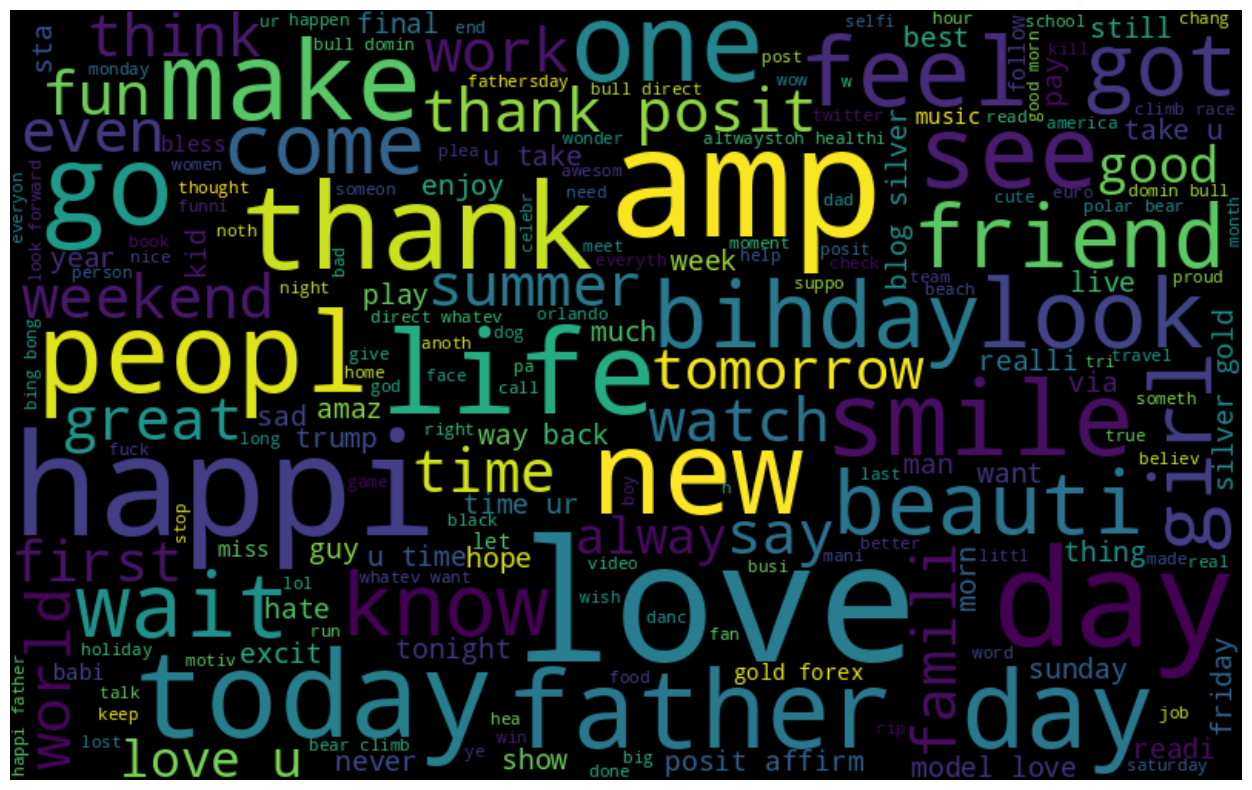

In [21]:
plt.figure(figsize=(16,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

### Positive Datasets

In [30]:
positive_words = ' '.join([text for text in positive_labels])
wordcloud_positive = word_cloud(positive_words)

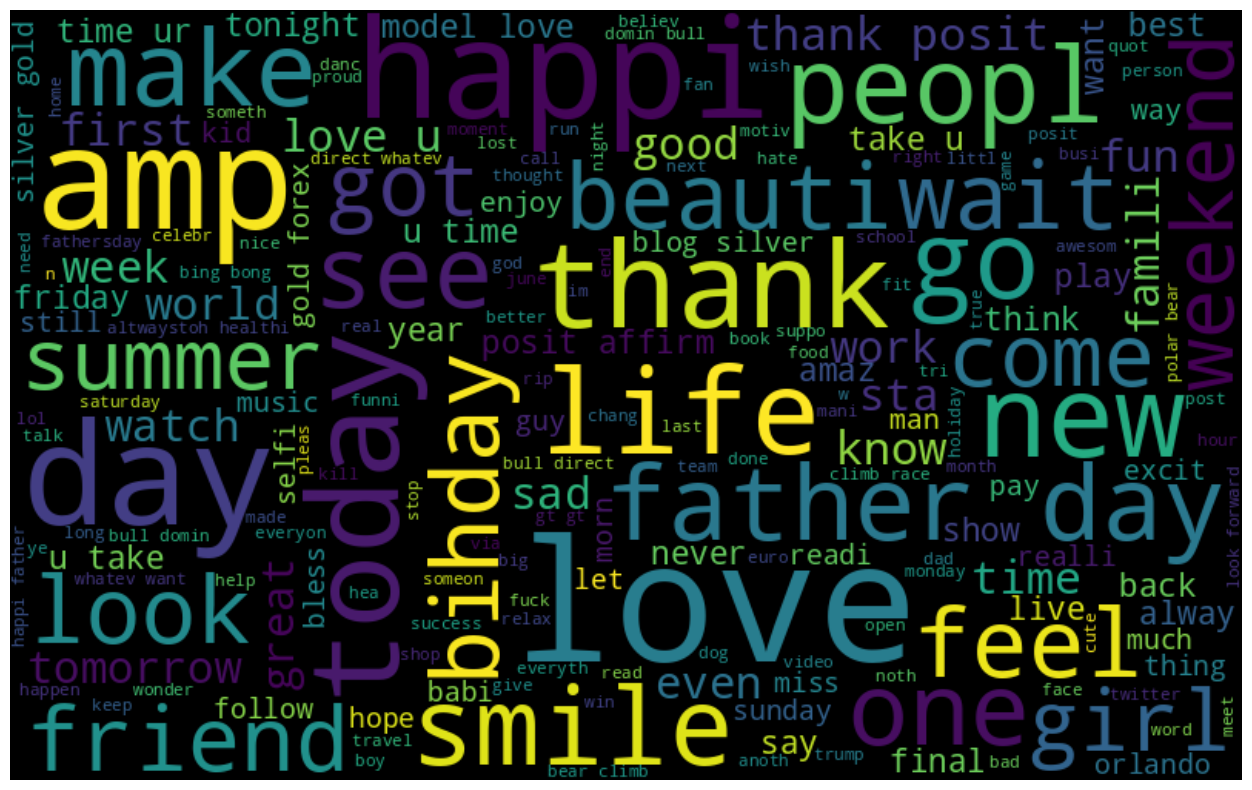

In [31]:
plt.figure(figsize=(16,10))
plt.imshow(wordcloud_positive,  interpolation='bilinear')
plt.axis('off')
plt.show()

Jika dilihat, ini sudah sesuai dengan kata-kata yang positif, seperti smile, love, thank, life, beauti,love u, friend.

### Negative Datasets

In [32]:
negative_words = ' '.join([text for text in negative_labels])
wordcloud_negative = word_cloud(negative_words)

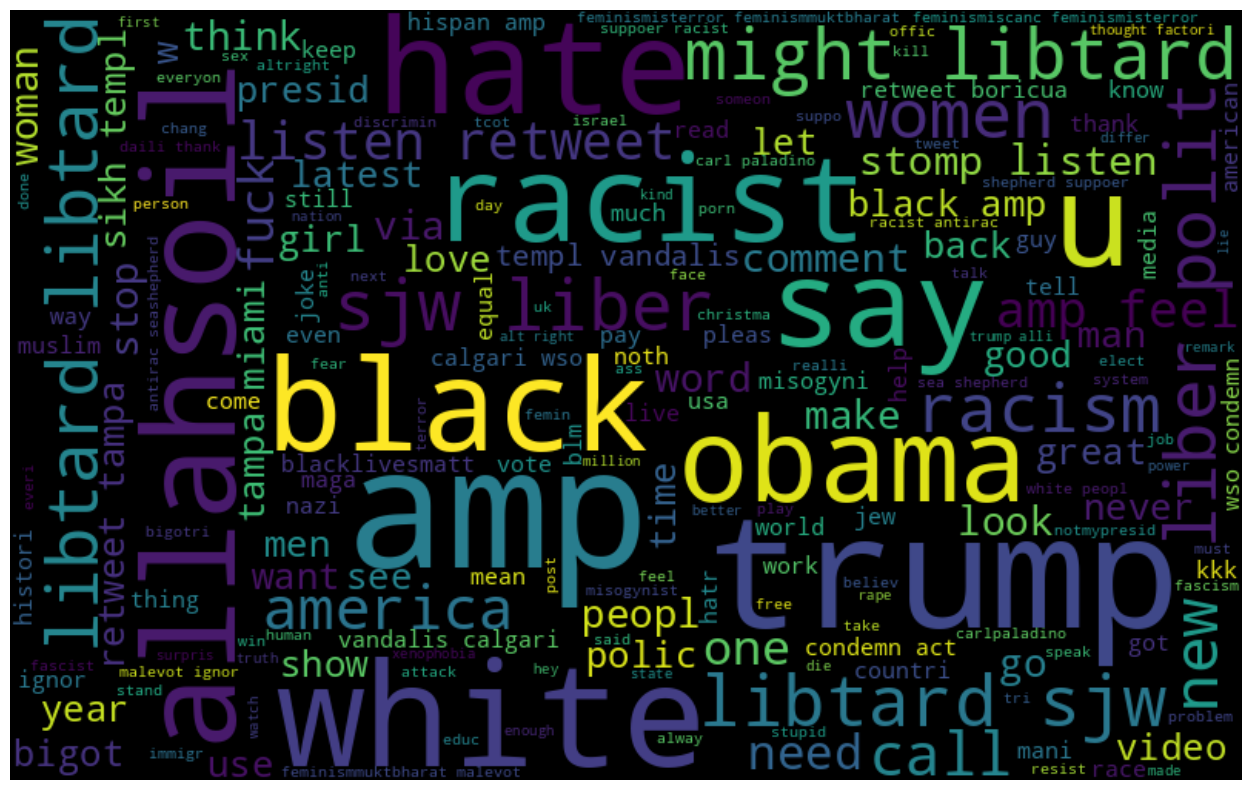

In [33]:
plt.figure(figsize=(16,10))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.show()           

Jika dilihat, data negatif juga sudah sesuai, seperti obama, trump, black, racist, hate, racism, america, dan lainnya, meskipun ada beberapa data yang masih termasuk kata positif.

## Understanding the impact of Hashtags on Tweets Sentiment

In [26]:
def hashtag_extract(x):
    hashtags = []

    for i in x:
        word_hash = re.findall(r'#(\w+)', i)
        hashtags.append(word_hash)
    return hashtags

In [38]:
hashtag_positive = hashtag_extract(positive_labels)
hashtag_negative = hashtag_extract(negative_labels)

hashtag_positive = sum(hashtag_positive, [])
hashtag_negative = sum(hashtag_negative, [])

### Non-Racism

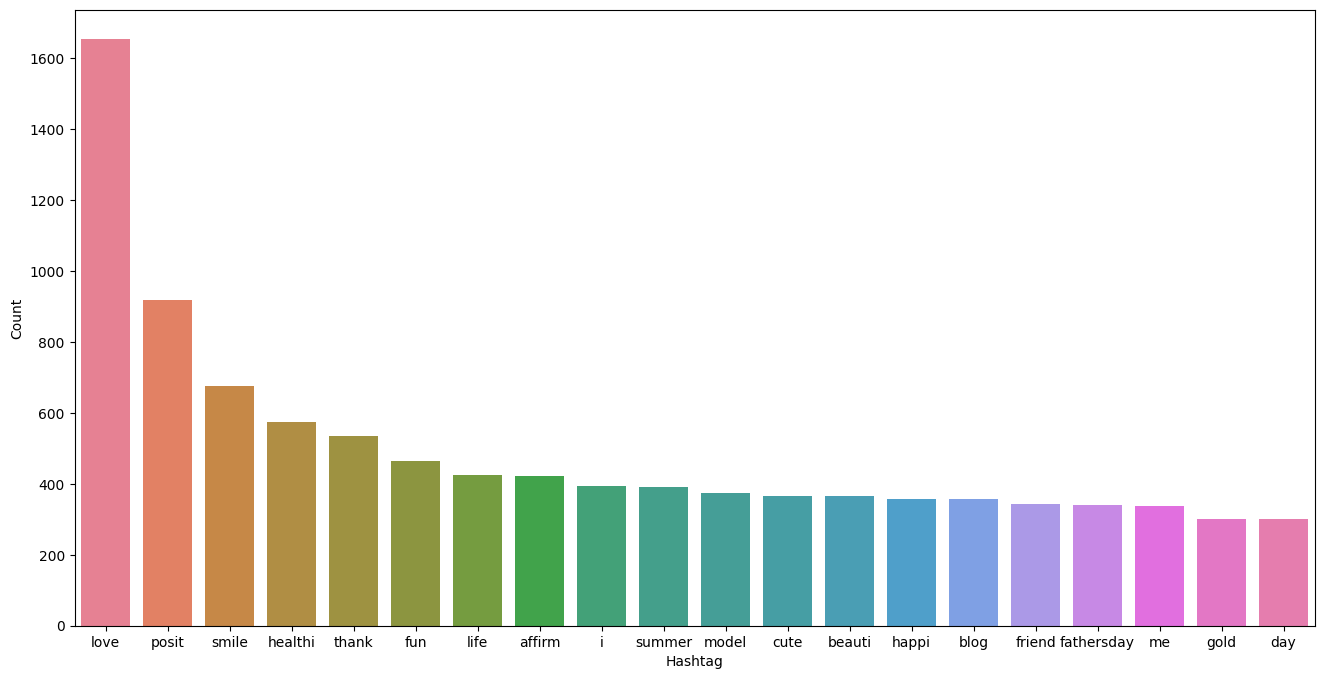

In [42]:
a = nltk.FreqDist(hashtag_positive)
d = pd.DataFrame({'Hashtag': list(a.keys()), 'Count': list(a.values())})

# Selecting Top 20 most frequent hashtags
d = d.nlargest(columns='Count', n=20)
plt.figure(figsize=(16,8))
ax = sns.barplot(data=d, x ='Hashtag', y='Count', hue='Hashtag', palette='husl', legend=False)
ax.set_xlabel('Hashtag')
ax.set_ylabel('Count')
plt.show()

### Racism